# (22) lite + lin decoder

project = ```iP-VAE```, host = ```yoru```, device = ```cuda:1```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, 'IterativeVAE'))
from figures.convergence import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: yoru

## Trainer

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs(model_type, 'vH16-wht', 'ngd|lin')

t_train = 10

cfg_vae['t_train'] = t_train
cfg_vae['beta_outer'] = 8/8 * t_train

cfg_vae['clamp_u'] = 8.0
cfg_vae['clamp_du'] = 10.0

cfg_vae['track_stats'] = True

cfg_tr['epochs'] = 300
cfg_tr['lr'] = 2e-3


In [4]:
cfg_vae['recon_mode'] = 'mse'
cfg_vae['fit_dec_var'] = False

In [5]:
from lite.ipvae import IPVAE
from lite.train import Trainer

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  132.1 K   |
|     ———     |    ———     |
|    layer    |  132.1 K   |
+-------------+------------+

poisson_vH16-wht_t-10_b-10_k-[512]_u-8,du-10
b200-ep300-lr(0.002)_temp(0.01:0.5)_gr(300)_(2025_05_22,19:57)

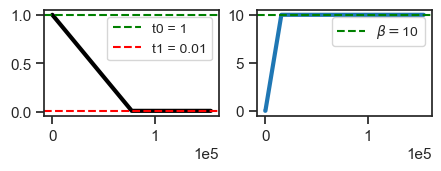

In [6]:
tr = Trainer(
    model=IPVAE(CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)

tr.model.print()
tr.print()
tr.show_schedules()

In [7]:
tr.n_iters

154500

In [8]:
cm = 'Lite'
tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

# tr.train()

epoch # 300, avg loss: 184.203: 100%|███████| 300/300 [1:12:03<00:00, 14.41s/it]


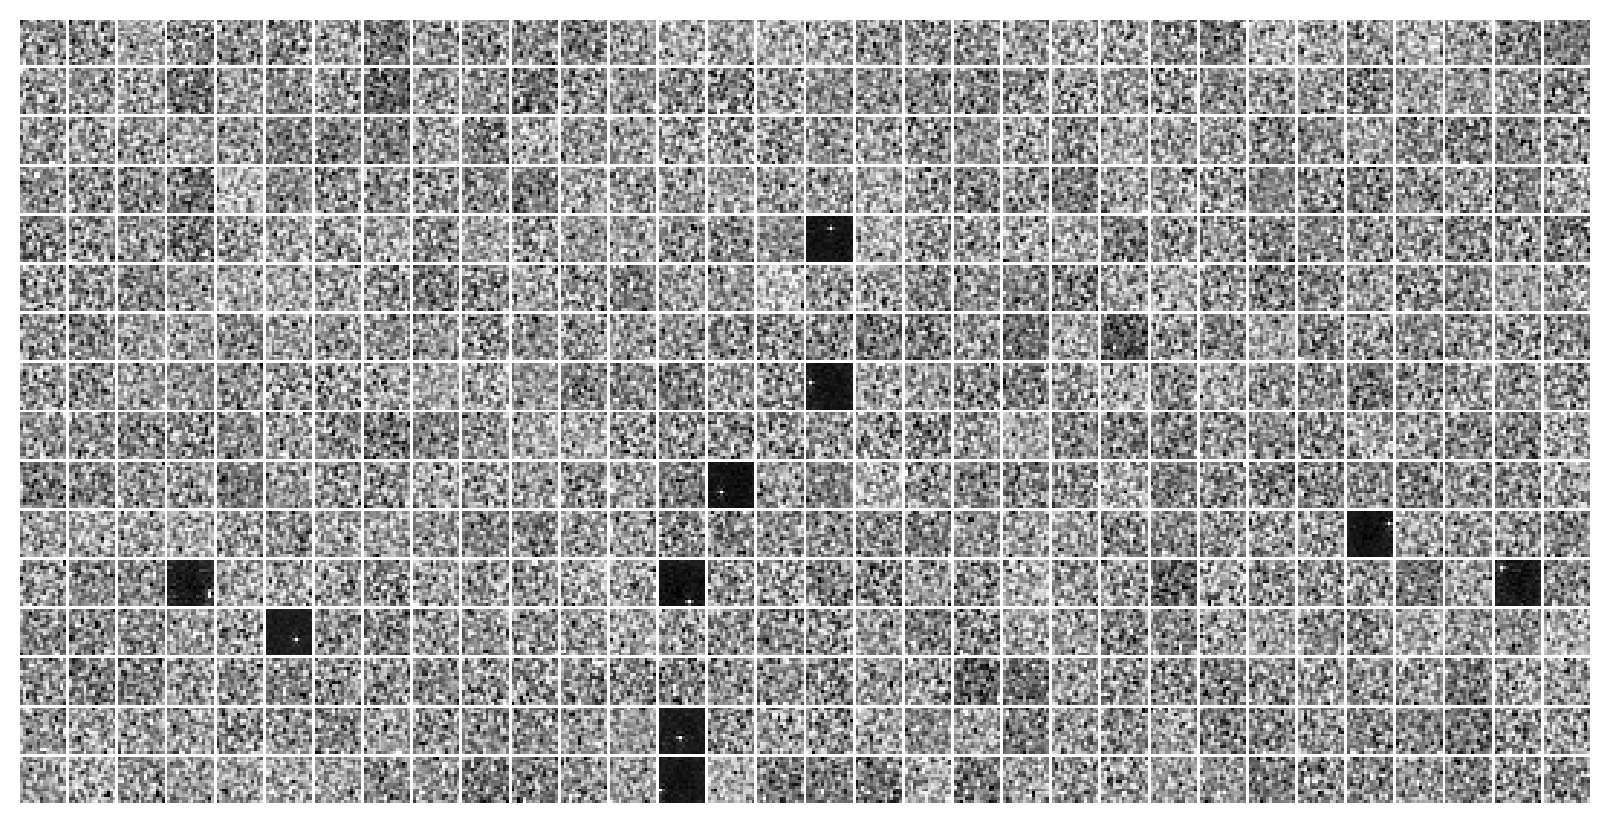

In [9]:
tr.model.show();

In [8]:
feeder = tr.get_feeder()

In [9]:
t = 0

x = feeder[t]
tr.model.update_time(t)

In [10]:
loss, posterior = tr._fun(x, 1.0)

In [11]:
loss

tensor(254.3410, device='cuda:1', grad_fn=<MeanBackward0>)

In [12]:
du = tr.model.layer(x)

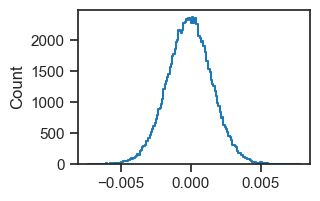

In [13]:
histplot(du.ravel())
plt.show()

In [14]:
du.max(), du.min()

(tensor(0.0078, device='cuda:1', grad_fn=<MaxBackward1>),
 tensor(-0.0074, device='cuda:1', grad_fn=<MinBackward1>))

epoch # 1, avg loss: 2057585803.463:   0%|    | 1/300 [01:17<6:27:28, 77.76s/it]


OutOfMemoryError: CUDA out of memory. Tried to allocate 8.56 GiB. GPU 1 has a total capacity of 47.54 GiB of which 2.27 GiB is free. Process 33646 has 1.27 GiB memory in use. Including non-PyTorch memory, this process has 43.99 GiB memory in use. Of the allocated memory 43.64 GiB is allocated by PyTorch, and 40.30 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [11]:
# tuple(llr.exp() for llr in tr.model.layer.log_lr)

In [9]:
print(tr.model.layer.n_exp)

tensor([21, 24, 26, 28, 30, 32, 33, 34, 35, 36], device='cuda:1',
       dtype=torch.int32)

100%|███████████████████████████████████| 2/2 [00:05<00:00,  2.65s/it]


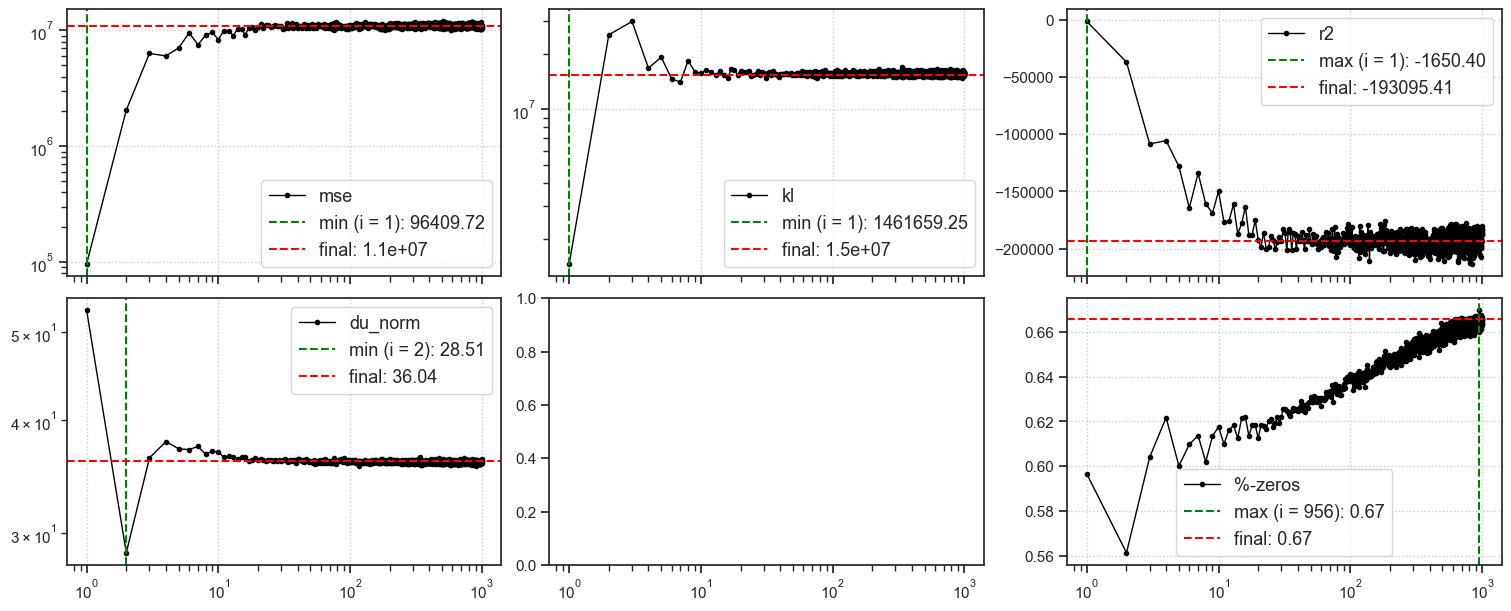

CPU times: user 6.53 s, sys: 60 ms, total: 6.59 s
Wall time: 6.58 s


In [10]:
%%time

kws = dict(
    t_total=1000,
    n_data_batches=2,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

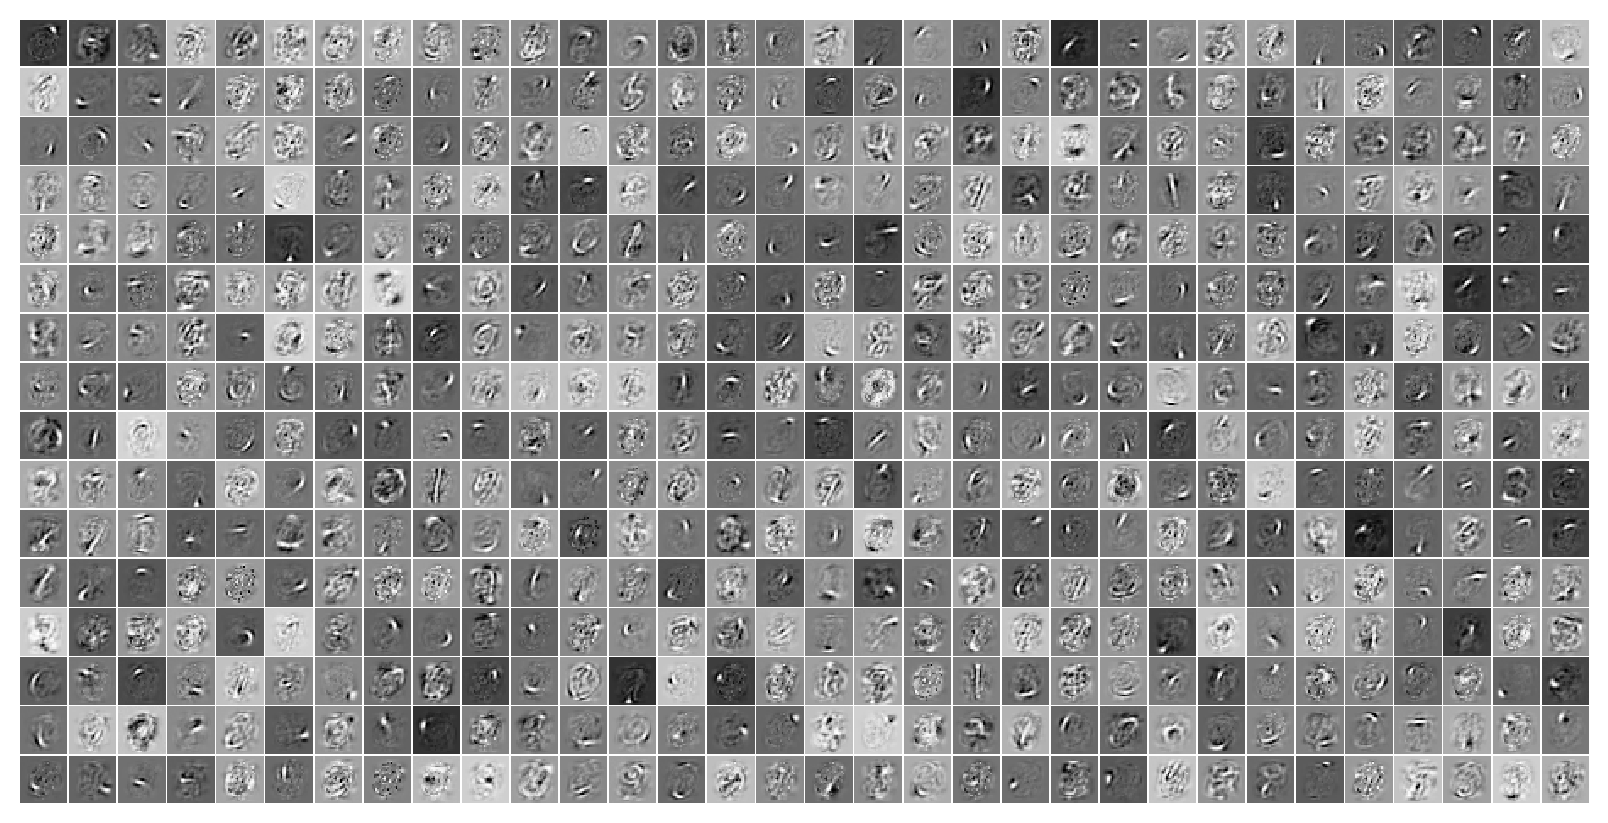

In [11]:
tr.model.show();

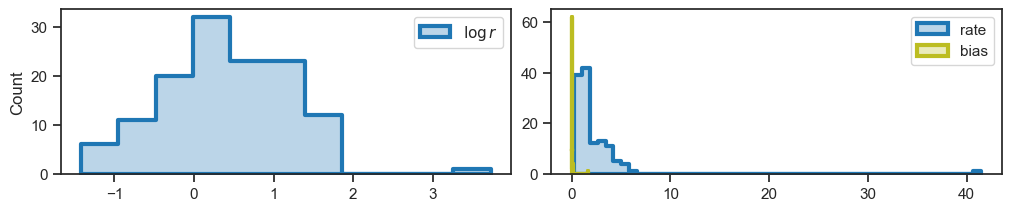

In [12]:
log_rate = tonp(tr.model.layer.u_init[0].squeeze())
bias = tonp(tr.model.layer.bias).ravel()

fig, axes = create_figure(1, 2, (10, 2))
kws = dict(fill=True, lw=3, alpha=0.3, ax=axes[0])
sns.histplot(log_rate, color='C0', element='step', label=r'$\log r$', **kws)

kws = dict(fill=True, lw=3, alpha=0.3, ax=axes[1])
sns.histplot(np.exp(log_rate), color='C0', element='step', label='rate', **kws)
sns.histplot(bias, color='C8', element='step', label='bias', **kws)

axes[1].set(ylabel='')
add_legend(axes)

plt.show()

In [13]:
bias = tonp(tr.model.layer.bias.squeeze())

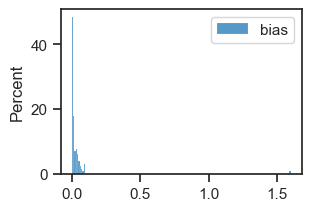

In [14]:
fig, ax = create_figure()

sns.histplot(bias, label='bias', stat='percent',  ax=ax)
ax.legend()
plt.show()

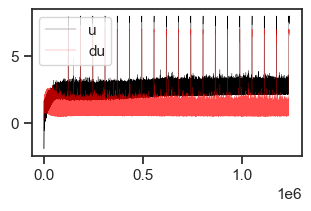

In [20]:
u_max = np.array(tr.model.stats['u_max'])
du_max = np.array(tr.model.stats['du_max'])

fig, ax = create_figure()
ax.plot(u_max, color='k', label='u', lw=0.2)
ax.plot(du_max, color='r', label='du', alpha=0.7, lw=0.2)
ax.legend()
plt.show()

In [38]:
x = next(iter(tr.dl_vld))[0]
feeder = tr.get_feeder(x)

In [39]:
for t in range(1000):
    tr.model.update_time(t)
    output = tr.model.xtract_ftr(
        feeder[t], return_extras=['r2', 'mse'])

In [40]:
list(output)

['loss_kl', 'loss_recon', 'posterior', 'r2', 'mse']

In [41]:
r2 = tonp(output['r2']).copy()
r2_good = r2[r2 > 0]
r2_bad = r2[r2 <= 0]

len(r2_good), len(r2_bad)

(154, 46)

In [43]:
r2_good.mean(), r2_bad.mean()

(0.8611522, -336156.8)